# 09 — Refined hypothesis tests

Same Stage 10 statistical machinery; new measurements. Side-by-side original vs refined
δ values are **not** claimed commensurable — they show how conclusions change after
measurement repair.

Sequence per axis: Cliff's δ → three-tier trend → quality/reach OLS with length+era+genre
controls and author-cluster-robust SE → measurement-gated verdict.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh

ctx = nh.setup("09_refined_hypothesis_tests")
cfg = ctx.cfg
GATE = nh.effect_gate(cfg)
delta_freeze = cfg.section("stage10_delta_freeze")
coverage = nh.load_construct_coverage(cfg)

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/09_refined_hypothesis_tests


In [2]:
frame = nh.load_refined_frame(cfg, "strict")
if "book_id" in frame.columns:
    frame = frame.set_index("book_id")
usable = frame[frame["analysable"].fillna(True)].copy() if "analysable" in frame.columns else frame.copy()
# Reset index for statsmodels helpers that expect columns
work = usable.reset_index()

FEATURES = [
    # (hyp, feature, label, expected_sign) — expected_sign only for primary hypothesis tests
    ("H1", "RLR_emotional_vs_explicit", "emotional vs explicit ratio", +1),
    ("H1", "RAX_nonexplicit_affection", "non-explicit affection", None),
    ("H1", "RAX_explicit_sex", "explicit sex", None),
    ("H1", "RAX_emotional_reassurance", "emotional reassurance", None),
    ("H2", "RAX_h2_strict", "strict final payoff", +1),
    ("H2", "RAX_h2_broad", "broad HEA/commitment", None),
    ("H2", "RAX_repair", "repair", None),
    ("H3", "RLR_emotional_vs_material_security", "emotional vs material security", +1),
    ("H3", "RAX_h3_emotional_side", "emotional security side", None),
    ("H3", "RAX_h3_material_side", "material provision side", None),
    ("H3", "RAX_appearance_grooming", "appearance / grooming", None),
    ("H3", "RAX_status_display", "status display", None),
    ("H3", "RAX_workplace_status", "workplace status", None),
    ("H3", "RAX_social_presentation", "social presentation (exploratory)", None),
    ("H4", "RLR_protection_vs_control", "protection vs possession", +1),
    ("H4", "RAX_h4_protection_side", "external protection", None),
    ("H4", "RAX_h4_possession_side", "possession / control", None),
    ("H4", "RAX_external_protection", "external protection (atom)", None),
    ("H4", "RAX_protective_commitment", "protective commitment", None),
    ("H4", "RAX_protective_care_broad", "protective care broad (exploratory)", None),
    ("H5", "RLR_darkness_vs_tenderness", "darkness vs tenderness", +1),
    ("H5", "RAX_relational_darkness", "interpersonal/conflict darkness", None),
    ("H5", "RAX_tenderness_core", "tenderness core", None),
    ("H5", "RAX_external_danger_crisis", "external danger / crisis", None),
    ("H5", "RAX_individual_distress", "individual distress", None),
    ("H6", "RARC", "refined arc contrast", +1),
    ("H6", "DELTA_rising", "rising Δ (end−begin)", None),
    ("H6", "DELTA_falling", "falling Δ (end−begin)", None),
]

PRIMARY_FEATURES = {
    "RLR_emotional_vs_explicit",
    "RAX_h2_strict",
    "RLR_emotional_vs_material_security",
    "RLR_protection_vs_control",
    "RLR_darkness_vs_tenderness",
    "RARC",
}

TIERS = ("low_rate", "mid_rate", "high_rate")
results = []
for hyp, feat, label, expected_sign in FEATURES:
    mgate = nh.gate_for_feature(coverage, feat)
    results.append(
        nh.test_axis(
            work,
            feat,
            hyp,
            label=label,
            tiers=TIERS,
            n_replicates=400,
            seed=42,
            measurement_gate=mgate,
            effect_gate=GATE,
            expected_sign=expected_sign,
        )
    )
effects = pd.DataFrame(results)

# FDR (Benjamini–Hochberg) on the six primary hypothesis tests only.
# Component / exploratory p-values remain unadjusted.
from src.stage10_correlation_analysis.analysis import tests as tst

primary_mask = effects["feature"].isin(PRIMARY_FEATURES)
primary = effects.loc[primary_mask].copy()
if len(primary):
    kw_adj = tst.adjust_within_family(primary, "kw_p_value", method="fdr_bh", alpha=0.05)
    effects.loc[primary_mask, "kw_q_value"] = kw_adj["q_value"].to_numpy()
    if "quality_p" in primary.columns:
        q_adj = tst.adjust_within_family(primary, "quality_p", method="fdr_bh", alpha=0.05)
        effects.loc[primary_mask, "quality_q"] = q_adj["q_value"].to_numpy()

display(effects.round(4))
ctx.save_table(effects, "refined_hypothesis_effects")

print(
    "Primary verdicts use expected direction (supported / directionally consistent / "
    "contradicted / no reliable effect), wrapped by measurement gates. "
    "FDR (BH) is applied only to the six primary kw_p / quality_p values; "
    "component analyses are exploratory/unadjusted."
)

# Post-freeze claim hierarchy (H3/H4 manual freeze applied)
CLAIM_HIERARCHY = [
    ("confirmatory", "H3", "RAX_h3_emotional_side", "Emotional reassurance/security positively associated with rating quality"),
    ("confirmatory", "H3", "RAX_appearance_grooming", "Appearance/grooming description negatively associated with rating quality"),
    ("qualified", "H5", "RAX_external_danger_crisis", "External danger positively associated with ratings"),
    ("open", "H4", "RAX_external_protection", "Is enacted protection within danger the attractive feature? (thin: 1 topic)"),
    ("unsupported", "H4", "RAX_protective_commitment", "Generic protective promises do not distinguish high-rated romance"),
    ("unmeasurable", "H3", "RLR_emotional_vs_material_security", "Material/economic security not cleanly captured at topic level"),
    ("unmeasurable", "H4", "RLR_protection_vs_control", "Protective commitment atom empty; protection side thin"),
]
claims_rows = []
for tier, hyp, feat, claim in CLAIM_HIERARCHY:
    row = effects[effects["feature"] == feat]
    delta = float(row.iloc[0]["cliffs_delta"]) if len(row) else float("nan")
    gate = row.iloc[0]["measurement_gate"] if len(row) else "missing"
    verdict = row.iloc[0]["verdict"] if len(row) else "missing"
    claims_rows.append(
        {
            "claim_tier": tier,
            "hypothesis": hyp,
            "feature": feat,
            "claim": claim,
            "measurement_gate": gate,
            "cliffs_delta": delta,
            "verdict": verdict,
        }
    )
claims_df = pd.DataFrame(claims_rows)
display(claims_df.round(4))
ctx.save_table(claims_df, "post_freeze_claim_hierarchy")
print(
    "H3 primary ratio and H4 protective commitment are unmeasurable after strict manual freeze; "
    "report emotional security + appearance (H3) and possession + exploratory protection (H4)."
)
# Compact δ view (backward-compatible table name)
delta_view = effects[
    [
        "hypothesis",
        "feature",
        "label",
        "measurement_gate",
        "cliffs_delta",
        "ci_low",
        "ci_high",
        "spearman_rho",
        "quality_beta",
        "quality_p",
        "reach_beta",
        "reach_p",
        "verdict",
    ]
].copy()
display(delta_view.round(4))
ctx.save_table(delta_view, "refined_hypothesis_delta_view")

,hypothesis,feature,label,status,measurement_gate,verdict,cliffs_delta,ci_low,ci_high,note,expected_sign,magnitude,epsilon_squared,kw_p_value,spearman_rho,quality_beta,quality_se,quality_p,quality_ci_low,quality_ci_high,reach_beta,reach_p,n_clusters,kw_q_value,quality_q
0,H1,RLR_emotional_vs_explicit,emotional vs explicit ratio,unmeasurable,unmeasurable,unmeasurable,NaN,NaN,NaN,zero or missing mapped topics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,H1,RAX_nonexplicit_affection,non-explicit affection,tested,thin,thin:directional_only,0.0405,0.0183,0.0612,,NaN,negligible,0.0009,0.0010,0.0283,0.9079,0.1853,0.0000,0.5448,1.2710,17.4211,0.0000,"8,263.0000",NaN,NaN
2,H1,RAX_explicit_sex,explicit sex,unmeasurable,unmeasurable,unmeasurable,NaN,NaN,NaN,zero or missing mapped topics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,H1,RAX_emotional_reassurance,emotional reassurance,tested,thin,thin:directional_only,0.0541,0.0304,0.0757,,NaN,negligible,0.0018,0.0000,0.0384,0.7204,0.1877,0.0001,0.3525,1.0884,17.4694,0.0000,"8,263.0000",NaN,NaN
4,H2,RAX_h2_strict,strict final payoff,unmeasurable,unmeasurable,unmeasurable,NaN,NaN,NaN,zero or missing mapped topics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,H2,RAX_h2_broad,broad HEA/commitment,unmeasurable,unmeasurable,unmeasurable,NaN,NaN,NaN,zero or missing mapped topics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,H2,RAX_repair,repair,unmeasurable,unmeasurable,unmeasurable,NaN,NaN,NaN,zero or missing mapped topics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,H3,RLR_emotional_vs_material_security,emotional vs material security,unmeasurable,unmeasurable,unmeasurable,NaN,NaN,NaN,zero or missing mapped topics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,H3,RAX_h3_emotional_side,emotional security side,tested,viable,directional_only,0.0726,0.0491,0.0952,,NaN,negligible,0.0026,0.0000,0.0507,0.5550,0.1489,0.0002,0.2631,0.8469,13.5621,0.0000,"8,263.0000",NaN,NaN
9,H3,RAX_h3_material_side,material provision side,unmeasurable,unmeasurable,unmeasurable,NaN,NaN,NaN,zero or missing mapped topics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/09_refined_hypothesis_tests/tables/refined_hypothesis_effects.csv  (28 rows)
Primary verdicts use expected direction (supported / directionally consistent / contradicted / no reliable effect), wrapped by measurement gates. FDR (BH) is applied only to the six primary kw_p / quality_p values; component analyses are exploratory/unadjusted.


,claim_tier,hypothesis,feature,claim,measurement_gate,cliffs_delta,verdict
0,confirmatory,H3,RAX_h3_emotional_side,Emotional reassurance/security positively asso...,viable,0.0726,directional_only
1,confirmatory,H3,RAX_appearance_grooming,Appearance/grooming description negatively ass...,viable,-0.1424,clears_gate
2,qualified,H5,RAX_external_danger_crisis,External danger positively associated with rat...,viable,0.1159,clears_gate
3,open,H4,RAX_external_protection,Is enacted protection within danger the attrac...,thin,0.1597,thin:clears_gate
4,unsupported,H4,RAX_protective_commitment,Generic protective promises do not distinguish...,unmeasurable,NaN,unmeasurable
5,unmeasurable,H3,RLR_emotional_vs_material_security,Material/economic security not cleanly capture...,unmeasurable,NaN,unmeasurable
6,unmeasurable,H4,RLR_protection_vs_control,Protective commitment atom empty; protection s...,thin,0.0898,"thin:directionally consistent, effect below th..."


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/09_refined_hypothesis_tests/tables/post_freeze_claim_hierarchy.csv  (7 rows)
H3 primary ratio and H4 protective commitment are unmeasurable after strict manual freeze; report emotional security + appearance (H3) and possession + exploratory protection (H4).


,hypothesis,feature,label,measurement_gate,cliffs_delta,ci_low,ci_high,spearman_rho,quality_beta,quality_p,reach_beta,reach_p,verdict
0,H1,RLR_emotional_vs_explicit,emotional vs explicit ratio,unmeasurable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unmeasurable
1,H1,RAX_nonexplicit_affection,non-explicit affection,thin,0.0405,0.0183,0.0612,0.0283,0.9079,0.0000,17.4211,0.0000,thin:directional_only
2,H1,RAX_explicit_sex,explicit sex,unmeasurable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unmeasurable
3,H1,RAX_emotional_reassurance,emotional reassurance,thin,0.0541,0.0304,0.0757,0.0384,0.7204,0.0001,17.4694,0.0000,thin:directional_only
4,H2,RAX_h2_strict,strict final payoff,unmeasurable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unmeasurable
5,H2,RAX_h2_broad,broad HEA/commitment,unmeasurable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unmeasurable
6,H2,RAX_repair,repair,unmeasurable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unmeasurable
7,H3,RLR_emotional_vs_material_security,emotional vs material security,unmeasurable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unmeasurable
8,H3,RAX_h3_emotional_side,emotional security side,viable,0.0726,0.0491,0.0952,0.0507,0.5550,0.0002,13.5621,0.0000,directional_only
9,H3,RAX_h3_material_side,material provision side,unmeasurable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unmeasurable


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/09_refined_hypothesis_tests/tables/refined_hypothesis_delta_view.csv  (28 rows)


## Side-by-side with Stage 10 primary δ

In [3]:
side = []
mapping = {
    "H1": ("RLR_emotional_vs_explicit", delta_freeze.get("H1")),
    "H2": ("RAX_h2_strict", delta_freeze.get("H2")),
    "H3": ("RLR_emotional_vs_material_security", delta_freeze.get("H3")),
    "H4": ("RLR_protection_vs_control", delta_freeze.get("H4")),
    "H5": ("RLR_darkness_vs_tenderness", delta_freeze.get("H5")),
    "H6": ("RARC", delta_freeze.get("H6")),
}
for hyp, (feat, old) in mapping.items():
    row = effects[effects["feature"] == feat]
    refined = float(row.iloc[0]["cliffs_delta"]) if len(row) else np.nan
    side.append(
        {
            "hypothesis": hyp,
            "original_delta": old,
            "refined_feature": feat,
            "refined_delta": refined,
            "measurement_gate": row.iloc[0]["measurement_gate"] if len(row) else "missing",
            "refined_verdict": row.iloc[0]["verdict"] if len(row) else "missing",
        }
    )
side_df = pd.DataFrame(side)
display(side_df)
ctx.save_table(side_df, "stage10_vs_stage11_side_by_side")

,hypothesis,original_delta,refined_feature,refined_delta,measurement_gate,refined_verdict
0,H1,-0.0290,RLR_emotional_vs_explicit,NaN,unmeasurable,unmeasurable
1,H2,0.0270,RAX_h2_strict,NaN,unmeasurable,unmeasurable
2,H3,-0.1460,RLR_emotional_vs_material_security,NaN,unmeasurable,unmeasurable
3,H4,0.0900,RLR_protection_vs_control,0.0898,thin,"thin:directionally consistent, effect below th..."
4,H5,0.0120,RLR_darkness_vs_tenderness,-0.0184,thin,thin:no reliable effect
5,H6,0.0440,RARC,-0.0528,viable,contradicted


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/09_refined_hypothesis_tests/tables/stage10_vs_stage11_side_by_side.csv  (6 rows)


## Forest plot — refined constructs vs rating tier

Each bar shows Cliff's δ between high- and low-rated books. Positive means more prevalent
in higher-rated books; negative means more prevalent in lower-rated books. The ±0.11 dashed
lines mark the pre-specified small-effect gate. Red bars indicate thin measurement
(construct rests on very few topics). Unmeasurable axes (H2/H3 primary ratios) are excluded.

| Code | Presentation label |
|---|---|
| `RLR_emotional_vs_explicit` | Emotional intimacy vs explicit sex |
| `RAX_emotional_reassurance` | Emotional reassurance |
| `RAX_nonexplicit_affection` | Non-explicit affection |
| `RAX_explicit_sex` | Explicit sex |
| `RLR_protection_vs_control` | Protection vs possessiveness |
| `RAX_external_protection` | Enacted protection |
| `RAX_h4_possession_side` | Possession / control |
| `RLR_darkness_vs_tenderness` | Darkness vs tenderness |
| `RAX_tenderness_core` | Tenderness |
| `RAX_external_danger_crisis` | External danger / crisis |
| `RAX_individual_distress` | Individual distress |
| `RAX_relational_darkness` | Relationship conflict / darkness |
| `RAX_appearance_grooming` | Appearance & grooming |
| `RAX_social_presentation` | Social presentation |
| `RARC` | Narrative arc: repair vs conflict |

  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/09_refined_hypothesis_tests/figures/refined_effects_forest.png


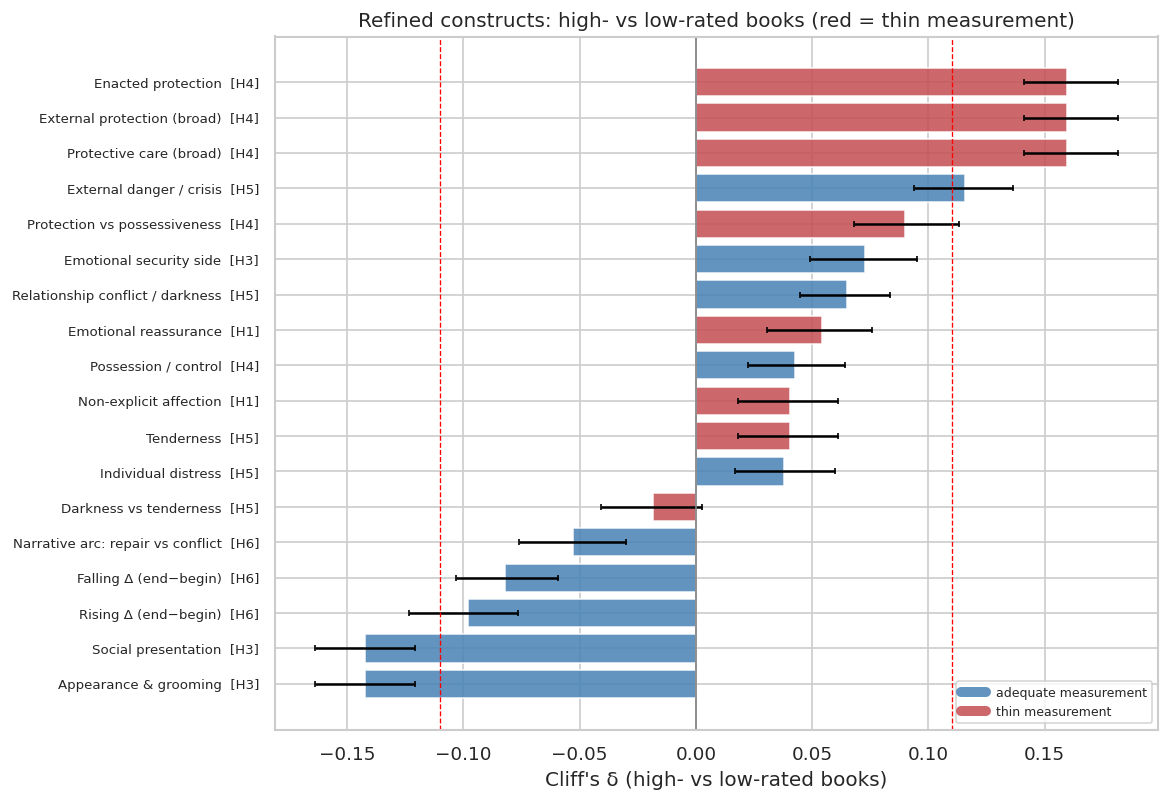

Effect gate |δ|≥0.11 with CI excluding 0. Unmeasurable axes are excluded from the forest; thin axes are flagged in red. Components take precedence when they disagree with composites.


In [4]:
_REFINED_HUMAN = {
    "RLR_emotional_vs_explicit": "Emotional intimacy vs explicit sex",
    "RAX_emotional_reassurance": "Emotional reassurance",
    "RAX_nonexplicit_affection": "Non-explicit affection",
    "RAX_explicit_sex": "Explicit sex",
    "RLR_emotional_vs_material_security": "Emotional vs material security",
    "RAX_h3_emotional_side": "Emotional security side",
    "RAX_h3_material_side": "Material provision",
    "RAX_appearance_grooming": "Appearance & grooming",
    "RAX_social_presentation": "Social presentation",
    "RLR_protection_vs_control": "Protection vs possessiveness",
    "RAX_h4_protection_side": "External protection (broad)",
    "RAX_h4_possession_side": "Possession / control",
    "RAX_external_protection": "Enacted protection",
    "RAX_protective_commitment": "Protective commitment",
    "RAX_protective_care_broad": "Protective care (broad)",
    "RLR_darkness_vs_tenderness": "Darkness vs tenderness",
    "RAX_relational_darkness": "Relationship conflict / darkness",
    "RAX_tenderness_core": "Tenderness",
    "RAX_external_danger_crisis": "External danger / crisis",
    "RAX_individual_distress": "Individual distress",
    "RARC": "Narrative arc: repair vs conflict",
    "DELTA_rising": "Rising Δ (end−begin)",
    "DELTA_falling": "Falling Δ (end−begin)",
    "RAX_h2_strict": "Strict final payoff",
    "RAX_h2_broad": "Broad HEA / commitment",
    "RAX_repair": "Repair",
    "RAX_status_display": "Status display",
    "RAX_workplace_status": "Workplace status",
}

plot_df = effects.dropna(subset=["cliffs_delta"]).copy()
plot_df = plot_df[plot_df["measurement_gate"] != "unmeasurable"]
plot_df = plot_df.sort_values("cliffs_delta")
fig, ax = plt.subplots(figsize=(9.5, 7.5))
y = np.arange(len(plot_df))
colors = [
    "#c44e52" if g == "thin" else "steelblue" for g in plot_df["measurement_gate"]
]
ax.barh(y, plot_df["cliffs_delta"], color=colors, alpha=0.85)
ax.errorbar(
    plot_df["cliffs_delta"],
    y,
    xerr=[
        plot_df["cliffs_delta"] - plot_df["ci_low"],
        plot_df["ci_high"] - plot_df["cliffs_delta"],
    ],
    fmt="none",
    ecolor="black",
    capsize=2,
)
ax.axvline(0, color="gray", lw=1)
ax.axvline(GATE, color="red", ls="--", lw=0.8)
ax.axvline(-GATE, color="red", ls="--", lw=0.8)
ax.set_yticks(y)
ax.set_yticklabels(
    [f"{_REFINED_HUMAN.get(r.feature, r.feature)}  [{r.hypothesis}]"
     for r in plot_df.itertuples()], fontsize=8
)
ax.set_xlabel("Cliff's δ (high- vs low-rated books)")
ax.set_title("Refined constructs: high- vs low-rated books (red = thin measurement)")
ax.legend(
    handles=[
        plt.Line2D([0], [0], color="steelblue", lw=6, alpha=0.85, label="adequate measurement"),
        plt.Line2D([0], [0], color="#c44e52", lw=6, alpha=0.85, label="thin measurement"),
    ],
    fontsize=7.5, loc="lower right", frameon=True,
)
ctx.save_figure(fig, "refined_effects_forest")
plt.show()

print(
    f"Effect gate |δ|≥{GATE} with CI excluding 0. "
    "Unmeasurable axes are excluded from the forest; thin axes are flagged in red. "
    "Components take precedence when they disagree with composites."
)